# Test on B Dataset (50-100 nodes)

Poređenje aproksimacionih algoritama na SteinLib B benchmark setu (J. E. Beasley).
Poznati optimumi se koriste za poređenje.

=== Small (10 instanci) ===

Instanca       N      E     T  Gustina  w_min  w_max   w_avg
------------------------------------------------------------
small01        5      7     3   0.7000      1      9     4.4
small02       10     15     4   0.3333      1      7     3.5
small03       15     25     5   0.2381      1     20     4.3
small04       20     40     6   0.2105      1     10     4.7
small05       25     50     7   0.1667      1     10     5.7
small06       26     52     7   0.1600      1     10     5.4
small07       27     54     7   0.1538      1     10     5.6
small08       28     56     8   0.1481      1     10     5.6
small09       29     58     8   0.1429      1     10     5.3
small10       30     60     8   0.1379      1     10     5.4

Prosek:       22     42     6   0.2391


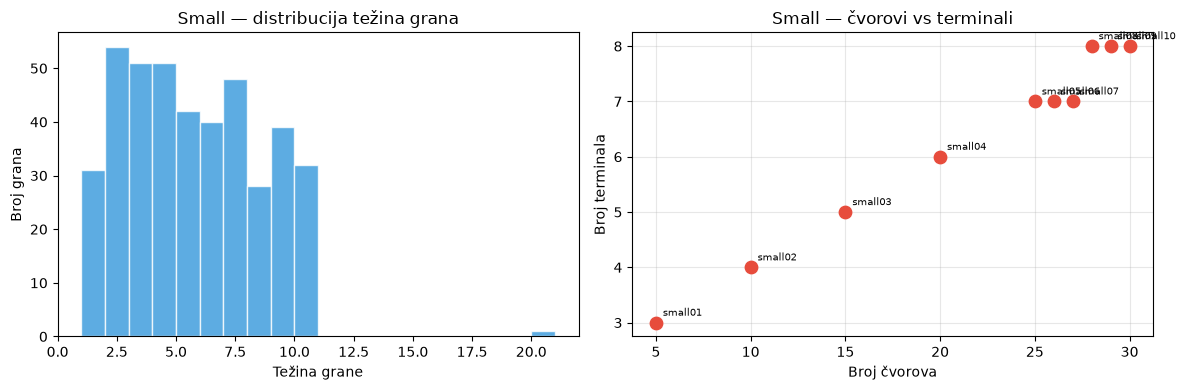

=== B (Beasley) (18 instanci) ===

Instanca       N      E     T  Gustina  w_min  w_max   w_avg
------------------------------------------------------------
B01           50     63     9   0.0514      1     10     5.7
B02           50     63    13   0.0514      1     10     5.6
B03           50     63    25   0.0514      1     10     5.2
B04           50    100     9   0.0816      1     10     6.1
B05           50    100    13   0.0816      1     10     5.3
B06           50    100    25   0.0816      1     10     5.7
B07           75     94    13   0.0339      1     10     5.5
B08           75     94    19   0.0339      1     10     5.3
B09           75     94    38   0.0339      1     10     5.2
B10           75    150    13   0.0541      1     10     5.7
B11           75    150    19   0.0541      1     10     5.1
B12           75    150    38   0.0541      1     10     5.7
B13          100    125    17   0.0253      1     10     5.7
B14          100    125    25   0.0253      1     

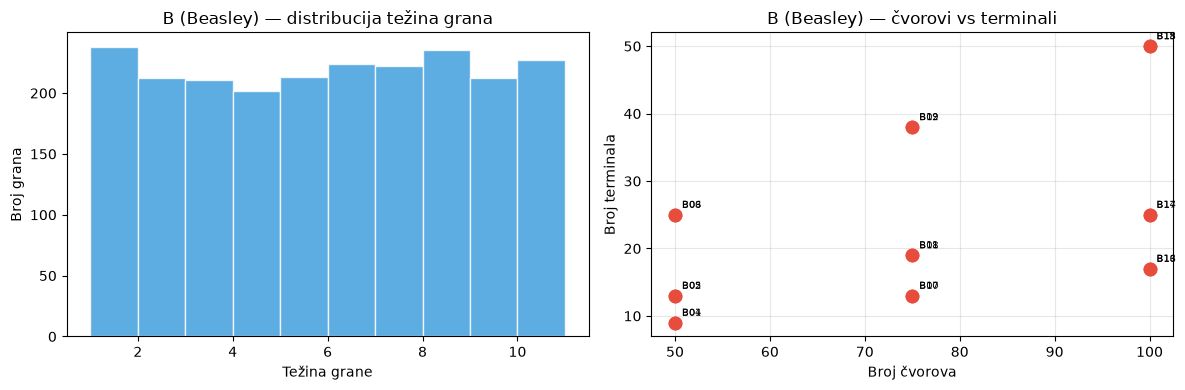

=== C (Beasley) (20 instanci) ===

Instanca       N      E     T  Gustina  w_min  w_max   w_avg
------------------------------------------------------------
C01          500    625     5   0.0050      1     10     5.6
C02          500    625    10   0.0050      1     10     5.5
C03          500    625    83   0.0050      1     10     5.5
C04          500    625   100   0.0050      1     10     5.5
C05          500    625   100   0.0050      1     10     5.6
C06          500   1000     5   0.0080      1     10     5.5
C07          500   1000    10   0.0080      1     10     5.5
C08          500   1000    83   0.0080      1     10     5.4
C09          500   1000   100   0.0080      1     10     5.5
C10          500   1000   100   0.0080      1     10     5.5
C11          500   2500     5   0.0200      1     10     5.5
C12          500   2500    10   0.0200      1     10     5.5
C13          500   2500    83   0.0200      1     10     5.6
C14          500   2500   100   0.0200      1     

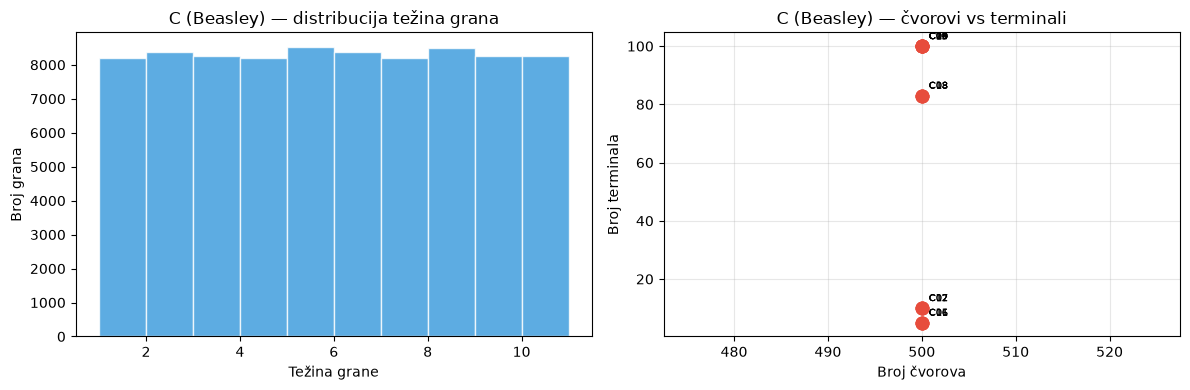

In [1]:
%run 02_evaluation_and_visualization.ipynb

In [2]:
b_files = sorted(Path('data/B').glob('*.stp'))

algorithms = [
    ('MST Heuristic', mst_heuristic, False),
    ('Mehlhorn', mehlhorn_steiner, False),
    ('SPH', sph_steiner, False),
    ('Zelikovsky', zelikovsky_steiner, False),
]

results = compare_algorithms_parallel(algorithms, b_files)

[72/72] B18 :: Zelikovsky               
Instance      N    T | MST He  Mehlho     SPH  Zeliko
-----------------------------------------------------
B01          50    9 |     82       *   85+4%       *
B02          50   13 |     90       *   84+-7%   88+-2%
B03          50   25 |    140       *  138+-1%       *
B04          50    9 |     64   59+-8%   59+-8%   59+-8%
B05          50   13 |     64       *   62+-3%       *
B06          50   25 |    128       *  127+-1%       *
B07          75   13 |    111       *       *       *
B08          75   19 |    104       *       *       *
B09          75   38 |    224  223+-0%  223+-0%       *
B10          75   13 |     98       *   95+-3%   94+-4%
B11          75   19 |     90   93+3%   88+-2%       *
B12          75   38 |    174       *       *       *
B13         100   17 |    175       *  178+2%       *
B14         100   25 |    237       *  239+1%       *
B15         100   50 |    325  326+0%  322+-1%       *
B16         100   17 |    1

## Poređenje težina

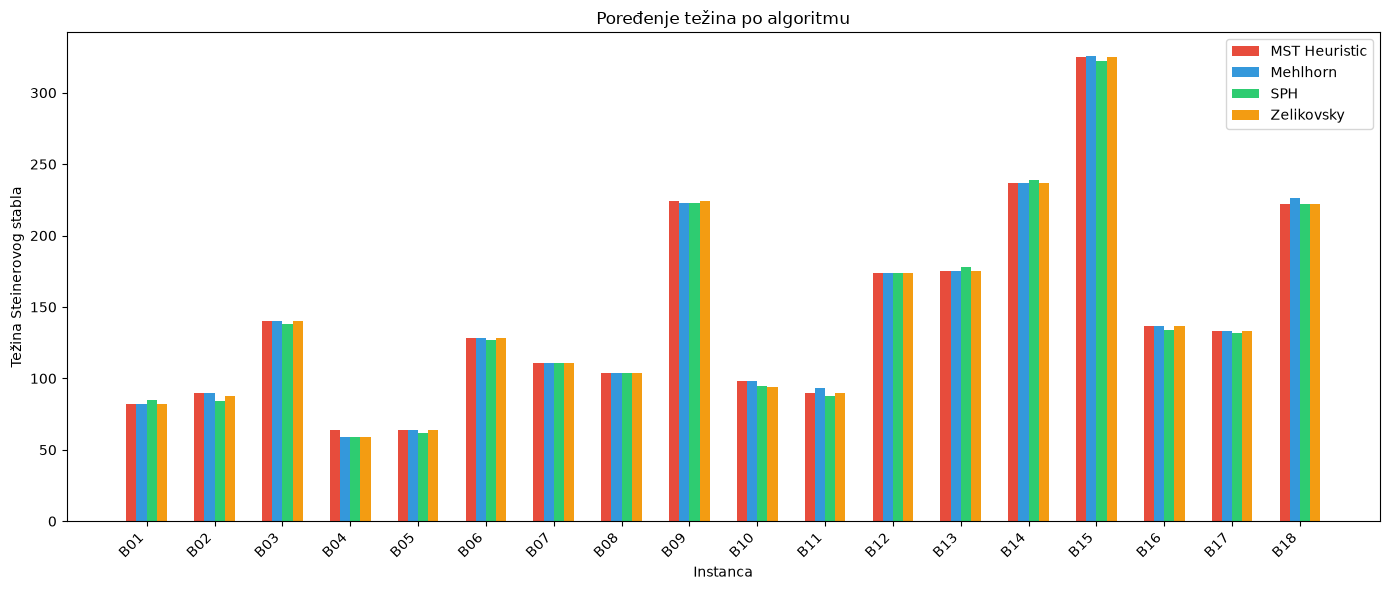

In [3]:
plot_weights(results, algorithms)

## Odstupanje od MST Heuristike

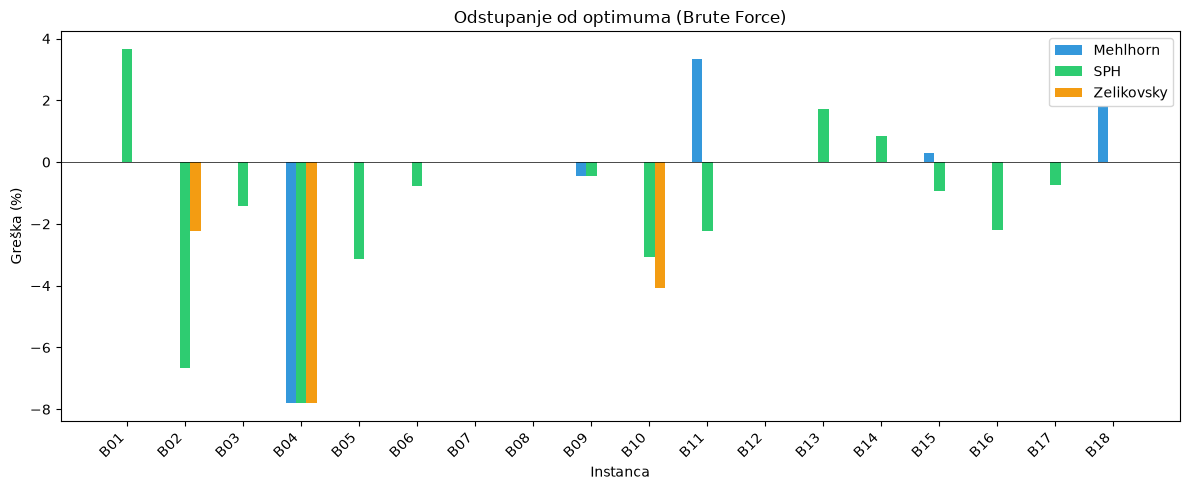

In [4]:
plot_errors(results, algorithms)

## Vreme izvršavanja

In [5]:
print_times(results, algorithms)

Instance      N    T |   MST Heur    Mehlhorn         SPH    Zelikovs
---------------------------------------------------------------------
B01          50    9 |     0.0027s     0.0017s     0.0101s     0.0121s
B02          50   13 |     0.0045s     0.0009s     0.0268s     0.0177s
B03          50   25 |     0.0127s     0.0011s     0.2566s     0.0502s
B04          50    9 |     0.0024s     0.0010s     0.0162s     0.0133s
B05          50   13 |     0.0043s     0.0013s     0.0350s     0.0162s
B06          50   25 |     0.0211s     0.0014s     1.3313s     0.0624s
B07          75   13 |     0.0045s     0.0011s     0.0883s     0.0363s
B08          75   19 |     0.0084s     0.0012s     0.2687s     0.0347s
B09          75   38 |     0.1025s     0.0016s     6.4088s     1.2965s
B10          75   13 |     0.0062s     0.0014s     0.4932s     0.0507s
B11          75   19 |     0.0487s     0.0017s     1.0104s     0.1011s
B12          75   38 |     0.2745s     0.0020s     4.9464s     3.0915s
B13     

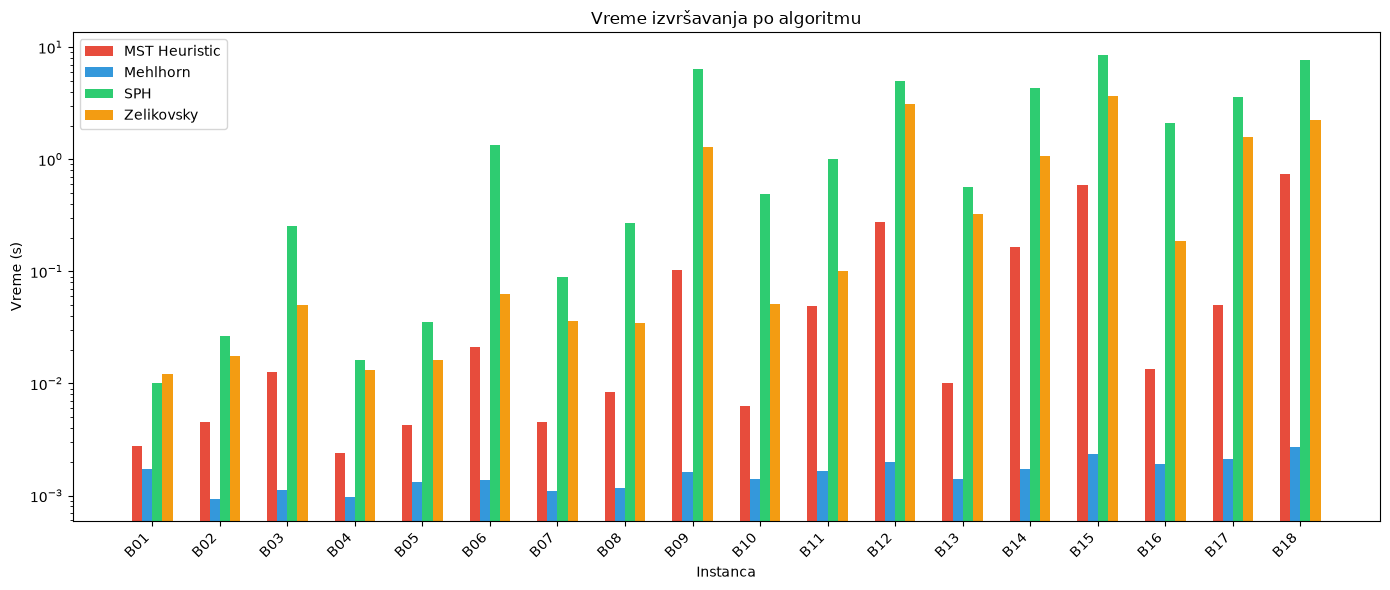

In [6]:
plot_times(results, algorithms)

## Prosečna greška po algoritmu

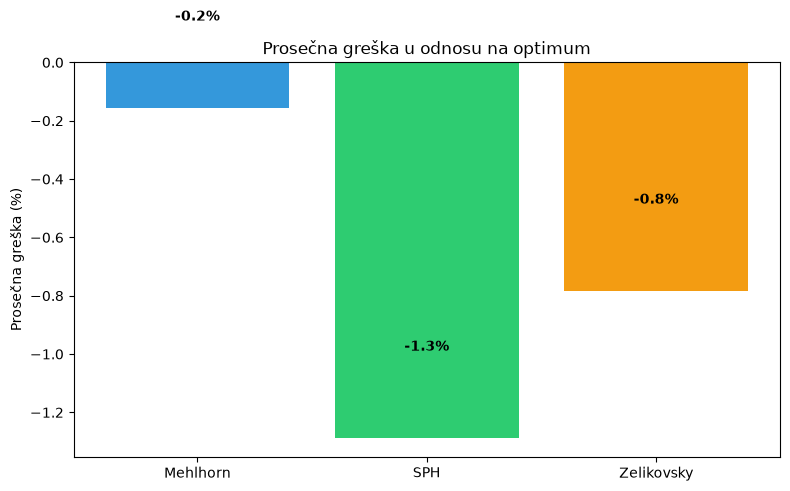

In [7]:
plot_avg_errors(results, algorithms)

## Brzina vs. kvalitet

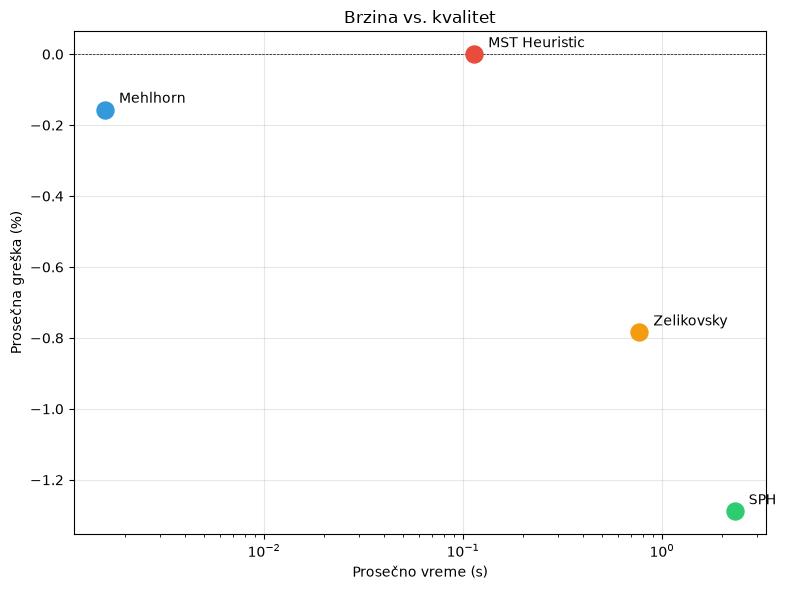

In [8]:
plot_speed_vs_quality(results, algorithms)

## Odnos težina (weight / MST Heuristic)

In [9]:
print_weight_ratios(results, algorithms)

Instance     OPT |   Mehlhorn         SPH    Zelikovs
-----------------------------------------------------
B01           82 |      1.0000      1.0366      1.0000
B02           90 |      1.0000      0.9333      0.9778
B03          140 |      1.0000      0.9857      1.0000
B04           64 |      0.9219      0.9219      0.9219
B05           64 |      1.0000      0.9688      1.0000
B06          128 |      1.0000      0.9922      1.0000
B07          111 |      1.0000      1.0000      1.0000
B08          104 |      1.0000      1.0000      1.0000
B09          224 |      0.9955      0.9955      1.0000
B10           98 |      1.0000      0.9694      0.9592
B11           90 |      1.0333      0.9778      1.0000
B12          174 |      1.0000      1.0000      1.0000
B13          175 |      1.0000      1.0171      1.0000
B14          237 |      1.0000      1.0084      1.0000
B15          325 |      1.0031      0.9908      1.0000
B16          137 |      1.0000      0.9781      1.0000
B17         

## Zelikovsky varijante (SPH i Mehlhorn baza)

In [10]:
algorithms_z = [
    ('Zelikovsky', zelikovsky_steiner, False),
    ('Zel+SPH', zelikovsky_sph, False),
    ('Zel+Mehlhorn', zelikovsky_mehlhorn, False),
]

results_z = compare_algorithms_parallel(algorithms_z, b_files)

[54/54] B18 :: Zel+Mehlhorn            
Instance      N    T | Zeliko  Zel+SP  Zel+Me
---------------------------------------------
B01          50    9 |     82   83+1%       *
B02          50   13 |     88   83+-6%       *
B03          50   25 |    140  138+-1%       *
B04          50    9 |     59       *       *
B05          50   13 |     64   62+-3%       *
B06          50   25 |    128  127+-1%       *
B07          75   13 |    111       *       *
B08          75   19 |    104       *       *
B09          75   38 |    224  223+-0%  220+-2%
B10          75   13 |     94   93+-1%   91+-3%
B11          75   19 |     90   88+-2%   93+3%
B12          75   38 |    174       *       *
B13         100   17 |    175  178+2%       *
B14         100   25 |    237  239+1%       *
B15         100   50 |    325  322+-1%  326+0%
B16         100   17 |    137  134+-2%       *
B17         100   25 |    133  132+-1%       *
B18         100   50 |    222       *  226+2%

* = optimalno resenje, - = 

## Poređenje svih 6 algoritama

In [11]:
results_all = []
for r, rz in zip(results, results_z):
    merged = dict(r)
    merged['Zel+SPH'] = rz['Zel+SPH']
    merged['Zel+SPH_time'] = rz['Zel+SPH_time']
    merged['Zel+Mehlhorn'] = rz['Zel+Mehlhorn']
    merged['Zel+Mehlhorn_time'] = rz['Zel+Mehlhorn_time']
    results_all.append(merged)

algorithms_all = [
    ('MST Heuristic', mst_heuristic, False),
    ('Mehlhorn', mehlhorn_steiner, False),
    ('SPH', sph_steiner, False),
    ('Zelikovsky', zelikovsky_steiner, False),
    ('Zel+SPH', zelikovsky_sph, False),
    ('Zel+Mehlhorn', zelikovsky_mehlhorn, False),
]

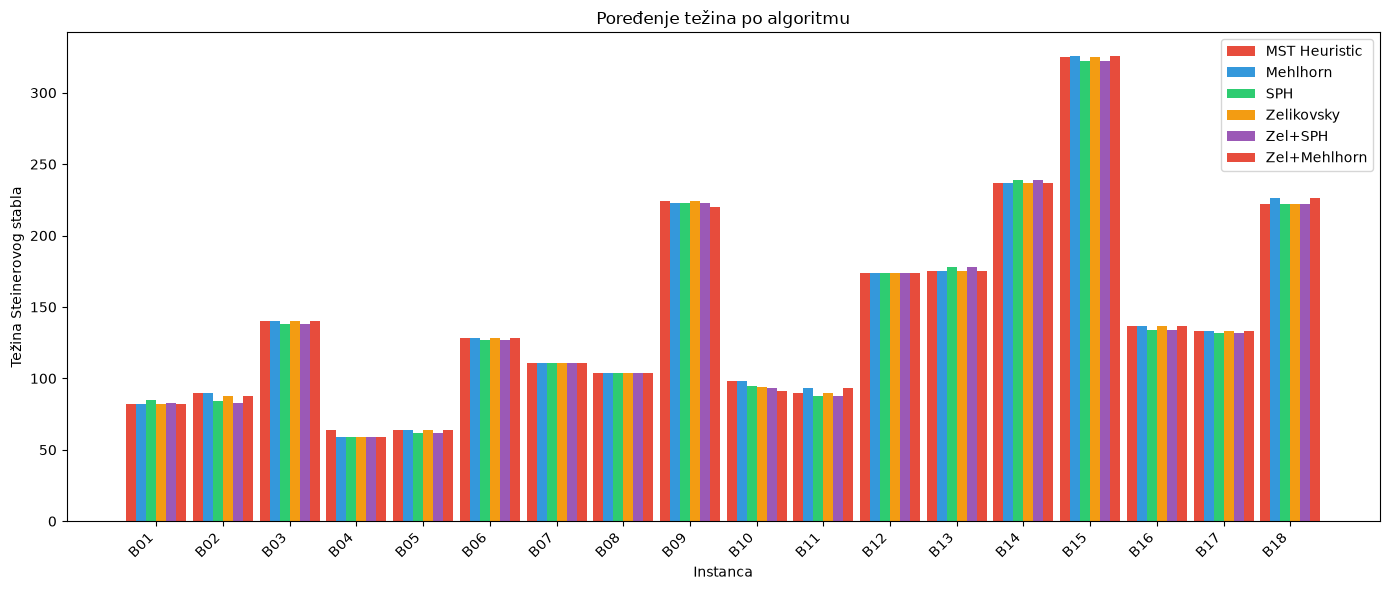

In [12]:
plot_weights(results_all, algorithms_all)

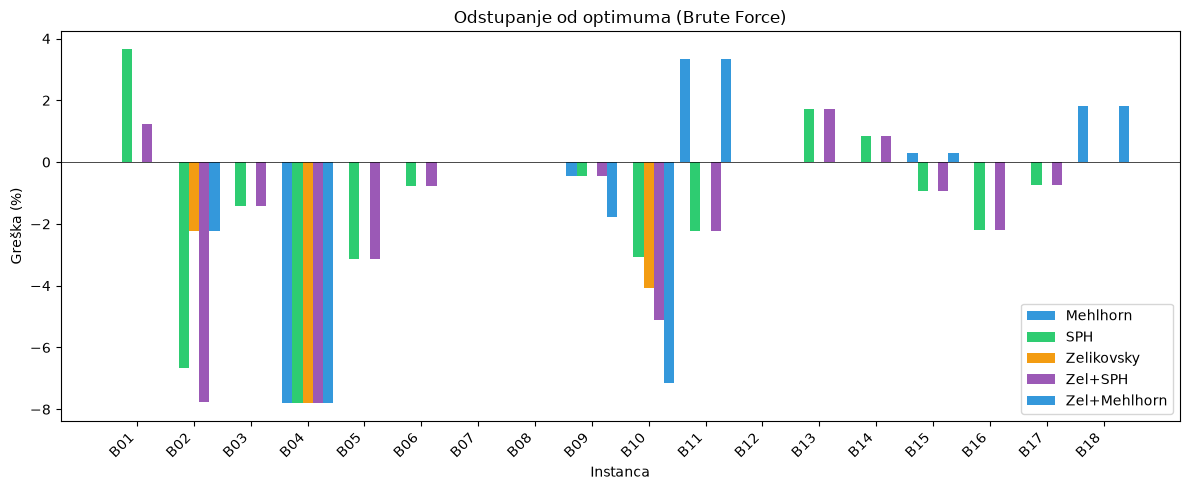

In [13]:
plot_errors(results_all, algorithms_all)

In [14]:
print_times(results_all, algorithms_all)

Instance      N    T |   MST Heur    Mehlhorn         SPH    Zelikovs     Zel+SPH    Zel+Mehl
---------------------------------------------------------------------------------------------
B01          50    9 |     0.0027s     0.0017s     0.0101s     0.0121s     0.0307s     0.0098s
B02          50   13 |     0.0045s     0.0009s     0.0268s     0.0177s     0.0386s     0.0139s
B03          50   25 |     0.0127s     0.0011s     0.2566s     0.0502s     0.4497s     0.1659s
B04          50    9 |     0.0024s     0.0010s     0.0162s     0.0133s     0.0258s     0.0108s
B05          50   13 |     0.0043s     0.0013s     0.0350s     0.0162s     0.1104s     0.0127s
B06          50   25 |     0.0211s     0.0014s     1.3313s     0.0624s     1.4551s     0.0551s
B07          75   13 |     0.0045s     0.0011s     0.0883s     0.0363s     0.2540s     0.0224s
B08          75   19 |     0.0084s     0.0012s     0.2687s     0.0347s     0.5505s     0.0295s
B09          75   38 |     0.1025s     0.0016s     6

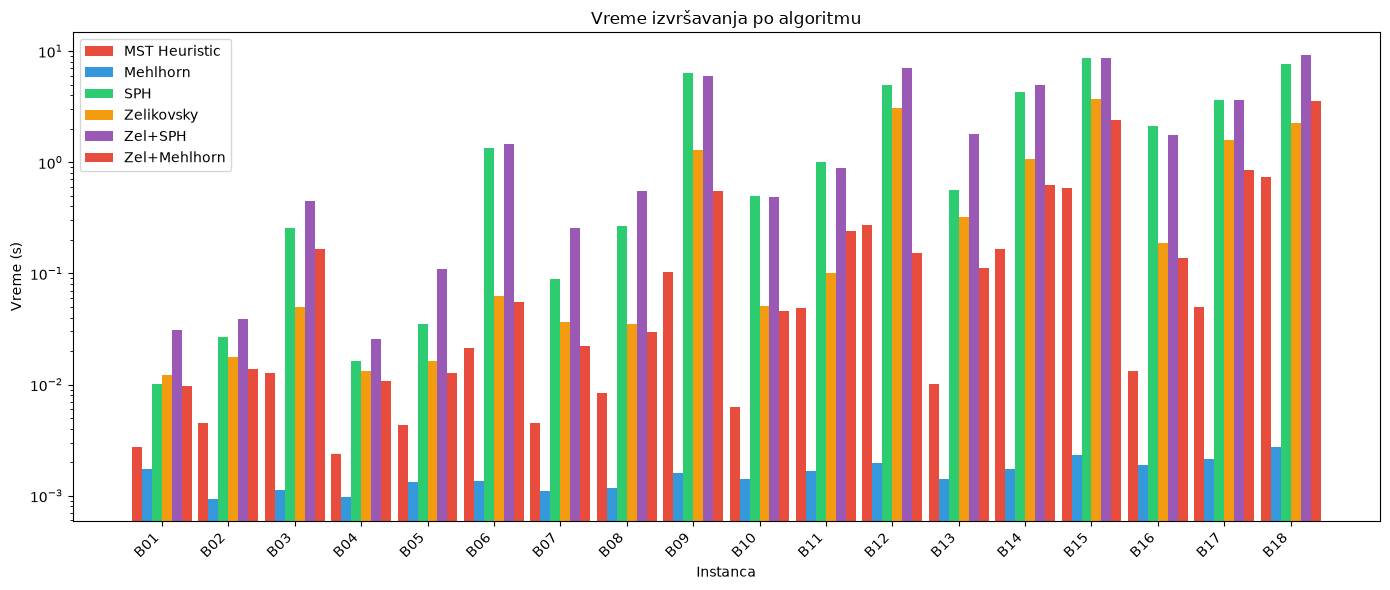

In [15]:
plot_times(results_all, algorithms_all)

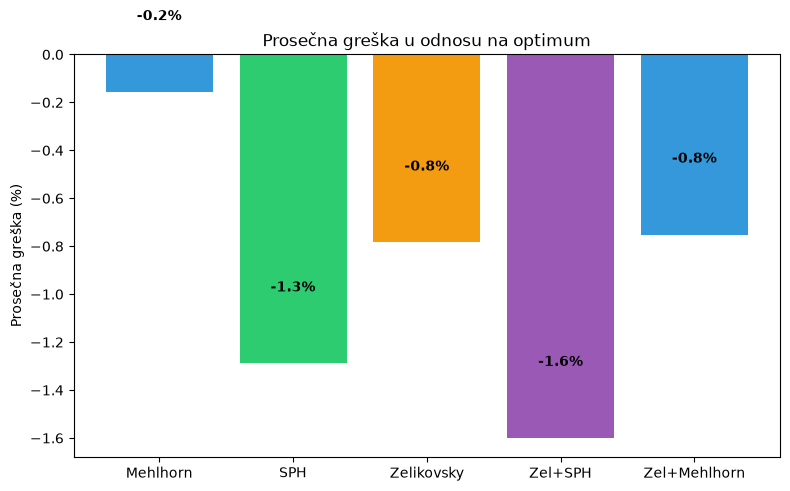

In [16]:
plot_avg_errors(results_all, algorithms_all)

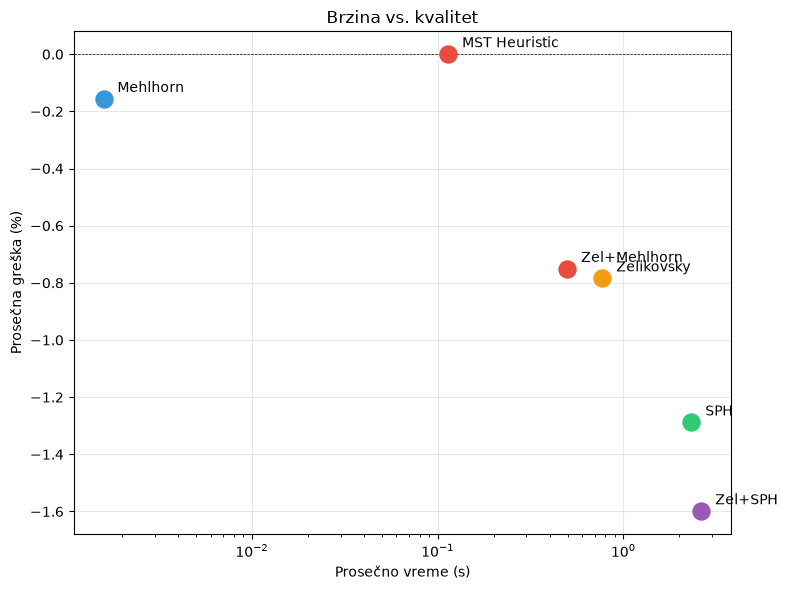

In [17]:
plot_speed_vs_quality(results_all, algorithms_all)

In [18]:
print_weight_ratios(results_all, algorithms_all)

Instance     OPT |   Mehlhorn         SPH    Zelikovs     Zel+SPH    Zel+Mehl
-----------------------------------------------------------------------------
B01           82 |      1.0000      1.0366      1.0000      1.0122      1.0000
B02           90 |      1.0000      0.9333      0.9778      0.9222      0.9778
B03          140 |      1.0000      0.9857      1.0000      0.9857      1.0000
B04           64 |      0.9219      0.9219      0.9219      0.9219      0.9219
B05           64 |      1.0000      0.9688      1.0000      0.9688      1.0000
B06          128 |      1.0000      0.9922      1.0000      0.9922      1.0000
B07          111 |      1.0000      1.0000      1.0000      1.0000      1.0000
B08          104 |      1.0000      1.0000      1.0000      1.0000      1.0000
B09          224 |      0.9955      0.9955      1.0000      0.9955      0.9821
B10           98 |      1.0000      0.9694      0.9592      0.9490      0.9286
B11           90 |      1.0333      0.9778      1.0000

## Zaključci

Na B datasetu (50–100 čvorova, 9–50 terminala) bez brute force-a, poređenje se vrši u odnosu na MST heuristiku kao bazni algoritam:

- **Mehlhorn** ostaje **najbrži** algoritam (0.001–0.003s po instanci) i daje rezultate praktično identične MST heuristici (prosečan odnos **0.9984**).
- **SPH** često daje **bolje rezultate od MST heuristike** (prosečan odnos **0.9871**), ali je značajno sporiji — do 8.6s na instancama sa 50 terminala. Na nekim instancama (B01, B13, B14) daje lošije rezultate, što pokazuje nestabilnost greedy pristupa.
- **Zelikovsky** je konzistentan — prosečan odnos **0.9922**, nikad lošiji od MST heuristike na ovom setu. Vreme je umereno (do ~3.7s).
- **Zel+SPH** daje **najbolji prosečni kvalitet** (**0.9840**), ali uz cenu najdužeg vremena izvršavanja (~9.3s na velikim instancama).
- **Zel+Mehlhorn** (0.9925) se ponekad pogorša u odnosu na čist Zelikovsky (npr. B11: +3%, B15: +0.3%) jer Mehlhorn daje drugačiju polaznu strukturu stabla.

Generalno, sa porastom broja terminala raste i razlika između algoritama. Za instance sa malo terminala (9–13) većina algoritama konvergira ka istom rešenju, dok se na instancama sa 38–50 terminala jasno izdvaja prednost Zelikovsky varijanti po kvalitetu i Mehlhorn-a po brzini.